In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

In [2]:
results = []

In [3]:
df1 = pd.read_csv("Telco-Customer-Churn.csv")
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df1 = df1.drop("customerID", axis=1)
df1["TotalCharges"] = pd.to_numeric(df1["TotalCharges"], errors="coerce")
df1.fillna(df1.median(numeric_only=True), inplace=True)

In [5]:
df1 = pd.get_dummies(df1, drop_first=True)

In [6]:
X = df1.drop("Churn_Yes", axis=1)
y = df1["Churn_Yes"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [10]:
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
print("Accuracy:", acc)
print("Recall:", rec)
print("ROC-AUC:", roc)
results.append(["Telco Churn", acc, rec, roc])

Accuracy: 0.8197303051809794
Recall: 0.5951742627345844
ROC-AUC: 0.8620040473257631


In [11]:
df2 = pd.read_csv("adult.csv")
df2.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [12]:
df2.replace("?", np.nan, inplace=True)

In [13]:
df2.dropna(inplace=True)

In [14]:
df2 = pd.get_dummies(df2, drop_first=True)

In [15]:
df2.columns

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week', 'workclass_Local-gov', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay', 'education_11th',
       'education_12th', 'education_1st-4th', 'education_5th-6th',
       'education_7th-8th', 'education_9th', 'education_Assoc-acdm',
       'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate',
       'education_HS-grad', 'education_Masters', 'education_Preschool',
       'education_Prof-school', 'education_Some-college',
       'marital.status_Married-AF-spouse', 'marital.status_Married-civ-spouse',
       'marital.status_Married-spouse-absent', 'marital.status_Never-married',
       'marital.status_Separated', 'marital.status_Widowed',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-clea

In [16]:
[col for col in df2.columns if "income" in col]

['income_>50K']

In [17]:
X = df2.drop("income_>50K", axis=1)
y = df2["income_>50K"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [25]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [26]:
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
print("Accuracy:", acc)
print("Recall:", rec)
print("ROC-AUC:", roc)
results.append(["Adult Dataset", acc, rec, roc])

Accuracy: 0.8420354715730151
Recall: 0.5986666666666667
ROC-AUC: 0.8969771306713731


In [27]:
df3 = pd.read_csv("WineQT.csv")
df3.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [28]:
df3.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [29]:
df3.drop("Id", axis=1, inplace=True)

In [30]:
df3["quality_label"] = (df3["quality"] >= 6).astype(int)

In [31]:
X = df3.drop(["quality", "quality_label"], axis=1)
y = df3["quality_label"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [35]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [36]:
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)
print("Accuracy:", acc)
print("Recall:", rec)
print("ROC-AUC:", roc)
results.append(["Wine Dataset", acc, rec, roc])

Accuracy: 0.7685589519650655
Recall: 0.7874015748031497
ROC-AUC: 0.8220626833410529


In [37]:
final_results = pd.DataFrame(
    results,
    columns=["Dataset", "Accuracy", "Recall", "ROC-AUC"]
)
final_results

,Dataset,Accuracy,Recall,ROC-AUC
0,Telco Churn,0.819730,0.595174,0.862004
1,Adult Dataset,0.842035,0.598667,0.896977
2,Wine Dataset,0.768559,0.787402,0.822063


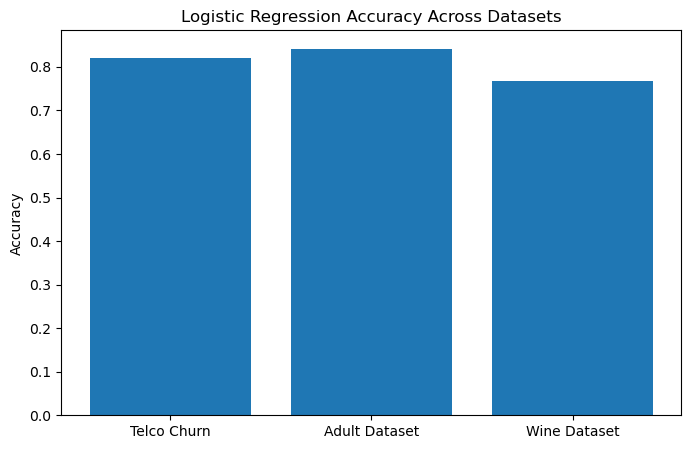

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(final_results["Dataset"], final_results["Accuracy"])
plt.title("Logistic Regression Accuracy Across Datasets")
plt.ylabel("Accuracy")
plt.show()

In [40]:
recall_weight = 0.5
roc_weight = 0.3
accuracy_weight = 0.2
final_results["Overall Score"] = (
    final_results["Recall"] * recall_weight +
    final_results["ROC-AUC"] * roc_weight +
    final_results["Accuracy"] * accuracy_weight
)

In [41]:
final_results["Rank"] = final_results["Overall Score"].rank(ascending=False)
final_results = final_results.sort_values(by="Rank")
final_results

,Dataset,Accuracy,Recall,ROC-AUC,Overall Score,Rank
2,Wine Dataset,0.768559,0.787402,0.822063,0.794031,1.0
1,Adult Dataset,0.842035,0.598667,0.896977,0.736834,2.0
0,Telco Churn,0.819730,0.595174,0.862004,0.720134,3.0


In [42]:
best_dataset = final_results.iloc[0]
print("Best Dataset for Logistic Regression:", best_dataset["Dataset"])

Best Dataset for Logistic Regression: Wine Dataset


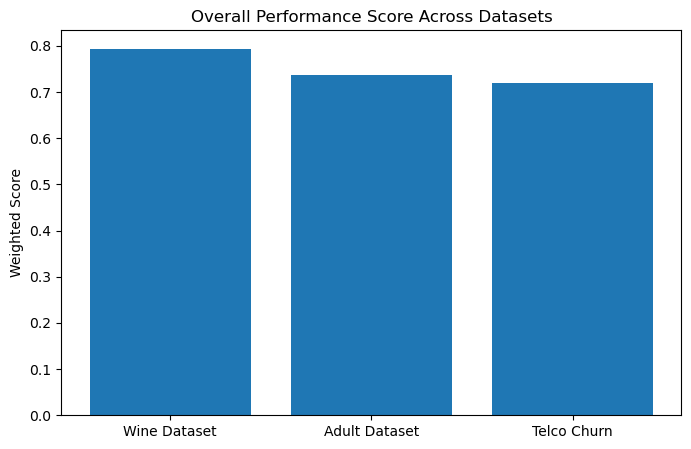

In [43]:
plt.figure(figsize=(8,5))
plt.bar(final_results["Dataset"], final_results["Overall Score"])
plt.title("Overall Performance Score Across Datasets")
plt.ylabel("Weighted Score")
plt.show()